# 💳 Loan Defaulter Prediction & Credit Risk Analysis
### An End-to-End Data Science, EDA, and Machine Learning Workflow

**Objective**: 
Develop an automated machine learning system to predict whether a loan applicant is likely to default (`loan_default = 1`) or repay their loan on time (`loan_default = 0`).

This notebook covers:
1. **Data Ingestion & Quality Audit**: Profiling missing values, duplicates, and real-world anomalies.
2. **Exploratory Data Analysis (EDA)**: Visualizing distributions and default rates across demographics, financial capacity, and loan purposes.
3. **Data Cleaning & Anomaly Correction**: Standardizing messy categoricals and rectifying corrupted numeric values.
4. **Feature Engineering**: Deriving domain-specific underwriting indicators (EMI, DTI, Loan-to-Income, Credit Risk Tiers).
5. **Model Benchmarking**: Comparing Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and LightGBM with 5-Fold Stratified Cross-Validation.
6. **Model Evaluation & Explainability**: Confusion matrices, ROC-AUC analysis, and top risk driver impacts.


## 1. Environment Setup & Data Ingestion
We load the required data science, machine learning, and visualization libraries, followed by importing the loan applications dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Visual style setup
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Load dataset
df_raw = pd.read_csv('loan_data.csv')
print(f"Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head()


Dataset Shape: 2085 rows, 16 columns


,loan_id,application_date,age,gender,marital_status,dependents,employment_type,monthly_income,credit_score,loan_amount,loan_term_months,interest_rate,loan_purpose,existing_loans_count,city,loan_default
0,LN100186,30-Mar-2022,51.0,Male,single,1,NaN,31790.18,737.0,268078.75,60,9.06,car,1,HYDERABAD,1
1,LN100801,27/04/2021,35.0,FEMALE,Married,1,selfemployed,59000.38,665.0,253839.61,12,8.84,education,0,hyderabad,1
2,LN101980,23/04/2017,18.0,f,Marreid,0,RETIRED,99675.29,660.0,534476.10,12,8.77,Personal,1,Madras,1
3,LN101433,2019-06-18,26.0,MALE,Married,2,Salaried,69537.66,786.0,63470.64,12,6.70,business,0,BANGALORE,0
4,LN100494,16-Jan-2016,71.0,f,Single,0,unemployed,-5000.00,589.0,169865.79,84,8.37,Business,0,chennai,0


## 2. Initial Data Audit & Anomaly Detection
Before any cleaning, we systematically identify dirty data patterns, missing values, duplicates, and corrupted values.


In [2]:
# 1. Check duplicate entries
exact_duplicates = df_raw.duplicated().sum()
id_duplicates = df_raw['loan_id'].str.strip().str.upper().duplicated().sum()

print("--- Data Quality Audit ---")
print(f"Exact Duplicate Rows: {exact_duplicates}")
print(f"Duplicate Loan IDs: {id_duplicates}")
print(f"Missing Values per Column:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")

print("\nTarget Variable Distribution:")
print(df_raw['loan_default'].value_counts(normalize=True).map(lambda x: f"{x*100:.2f}%"))


--- Data Quality Audit ---
Exact Duplicate Rows: 40
Duplicate Loan IDs: 85
Missing Values per Column:
age                58
marital_status     51
employment_type    65
monthly_income     61
credit_score       58
loan_purpose       53
city               37
dtype: int64

Target Variable Distribution:
loan_default
0    58.80%
1    41.20%
Name: proportion, dtype: str


### Data Audit Observations:
- **Duplicates**: There are 40 exact duplicate rows and 85 duplicate `loan_id` entries that must be deduplicated.
- **Missing Values**: Present in `age`, `marital_status`, `employment_type`, `monthly_income`, `credit_score`, `loan_purpose`, and `city`.
- **Target Distribution**: Approximately **58.4% Non-Defaulters** and **41.6% Defaulters**, showing a balanced binary classification target with no extreme class imbalance.


In [3]:
# Check for impossible numeric values and domain anomalies
print("Numerical Anomalies Checklist:")
print(f"• Age < 18 (minors): {(df_raw['age'] < 18).sum()}")
print(f"• Age > 90 (extreme outliers): {(df_raw['age'] > 90).sum()}")
print(f"• Monthly Income <= 0: {(df_raw['monthly_income'] <= 0).sum()}")
print(f"• Monthly Income > 1,000,000: {(df_raw['monthly_income'] > 1000000).sum()}")
print(f"• Credit Score outside [300, 900]: {((df_raw['credit_score'] < 300) | (df_raw['credit_score'] > 900)).sum()}")
print(f"• Loan Amount <= 0 or > 10M: {((df_raw['loan_amount'] <= 0) | (df_raw['loan_amount'] > 10000000)).sum()}")
print(f"• Loan Term = 1200 months (typo): {(df_raw['loan_term_months'] == 1200).sum()}")
print(f"• Interest Rate > 50%: {(df_raw['interest_rate'] > 50).sum()}")


Numerical Anomalies Checklist:
• Age < 18 (minors): 78
• Age > 90 (extreme outliers): 5
• Monthly Income <= 0: 7
• Monthly Income > 1,000,000: 3
• Credit Score outside [300, 900]: 13
• Loan Amount <= 0 or > 10M: 10
• Loan Term = 1200 months (typo): 7
• Interest Rate > 50%: 3


## 3. Data Cleaning & Normalization Pipeline
We build functions to standardize text variations, correct clerical typos, and clip impossible values to realistic bounds.


In [4]:
def clean_loan_dataset(df_in):
    df = df_in.copy()
    
    # 1. Remove duplicate records
    df = df.drop_duplicates()
    df['clean_id'] = df['loan_id'].astype(str).str.strip().str.upper()
    df = df.drop_duplicates(subset=['clean_id']).drop(columns=['clean_id'])
    
    # 2. Standardize Gender
    gender_map = {
        'MALE': 'Male', 'Male': 'Male', 'male': 'Male', 'M': 'Male', 'm': 'Male',
        'FEMALE': 'Female', 'Female': 'Female', 'female': 'Female', 'F': 'Female', 'f': 'Female'
    }
    df['gender'] = df['gender'].astype(str).str.strip().map(gender_map).fillna('Male')
    
    # 3. Standardize Marital Status
    marital_map = {
        'SINGLE': 'Single', 'Single': 'Single', 'single': 'Single',
        'MARRIED': 'Married', 'Married': 'Married', 'married': 'Married', 'Marreid': 'Married',
        'DIVORCED': 'Divorced', 'Divorced': 'Divorced', 'divorced': 'Divorced'
    }
    df['marital_status'] = df['marital_status'].astype(str).str.strip().map(marital_map).fillna('Single')
    
    # 4. Standardize Employment Type
    def clean_emp(val):
        if pd.isna(val): return 'Salaried'
        v = str(val).strip().lower()
        if 'salar' in v: return 'Salaried'
        if 'self' in v: return 'Self-Employed'
        if 'retir' in v: return 'Retired'
        if 'unemploy' in v: return 'Unemployed'
        return 'Salaried'
    df['employment_type'] = df['employment_type'].apply(clean_emp)
    
    # 5. Standardize Loan Purpose
    def clean_purpose(val):
        if pd.isna(val): return 'Personal'
        v = str(val).strip().lower()
        if 'auto' in v or 'car' in v: return 'Auto'
        if 'biz' in v or 'business' in v: return 'Business'
        if 'edu' in v: return 'Education'
        if 'home' in v or 'hous' in v: return 'Home'
        return 'Personal'
    df['loan_purpose'] = df['loan_purpose'].apply(clean_purpose)
    
    # 6. Standardize City
    def clean_city(val):
        if pd.isna(val): return 'Hyderabad'
        v = str(val).strip().lower()
        if 'hyderabad' in v: return 'Hyderabad'
        if 'pune' in v: return 'Pune'
        if 'chennai' in v or 'madras' in v: return 'Chennai'
        if 'delhi' in v: return 'Delhi'
        if 'bangalore' in v or 'bengaluru' in v: return 'Bengaluru'
        if 'mumbai' in v or 'bombay' in v: return 'Mumbai'
        return 'Hyderabad'
    df['city'] = df['city'].apply(clean_city)
    
    # 7. Numeric Cleaning
    df.loc[df['loan_term_months'] == 1200, 'loan_term_months'] = 120
    df['loan_term_months'] = df['loan_term_months'].clip(12, 120)
    
    df.loc[df['interest_rate'] > 50, 'interest_rate'] = df.loc[df['interest_rate'] > 50, 'interest_rate'] / 10.0
    df.loc[df['interest_rate'] <= 0, 'interest_rate'] = np.nan
    
    df.loc[(df['age'] < 18) | (df['age'] > 90), 'age'] = np.nan
    df.loc[(df['credit_score'] < 300) | (df['credit_score'] > 900), 'credit_score'] = np.nan
    df.loc[(df['monthly_income'] <= 0) | (df['monthly_income'] > 1000000), 'monthly_income'] = np.nan
    df.loc[(df['loan_amount'] <= 0) | (df['loan_amount'] > 10000000), 'loan_amount'] = np.nan
    
    df['dependents'] = df['dependents'].clip(0, 8)
    df['existing_loans_count'] = df['existing_loans_count'].clip(0, 10)
    
    return df

df_cleaned = clean_loan_dataset(df_raw)
print(f"Cleaned dataset shape: {df_cleaned.shape}")
df_cleaned.describe().T[['count', 'mean', 'min', '50%', 'max']]


Cleaned dataset shape: (2000, 16)


,count,mean,min,50%,max
age,1865.0,38.529759,18.00,38.000,75.00
dependents,2000.0,1.239000,0.00,1.000,8.00
monthly_income,1930.0,55805.242200,9764.91,49473.380,280638.83
credit_score,1930.0,649.595855,346.00,651.000,896.00
loan_amount,1990.0,259782.505085,20000.00,198499.705,4571532.18
loan_term_months,2000.0,55.230000,12.00,48.000,120.00
interest_rate,1995.0,10.823338,0.64,10.870,20.86
existing_loans_count,2000.0,1.012500,0.00,1.000,10.00
loan_default,2000.0,0.416000,0.00,0.000,1.00


## 4. Exploratory Data Analysis & Visualizations
We analyze the core financial drivers of default risk across demographics and credit health.


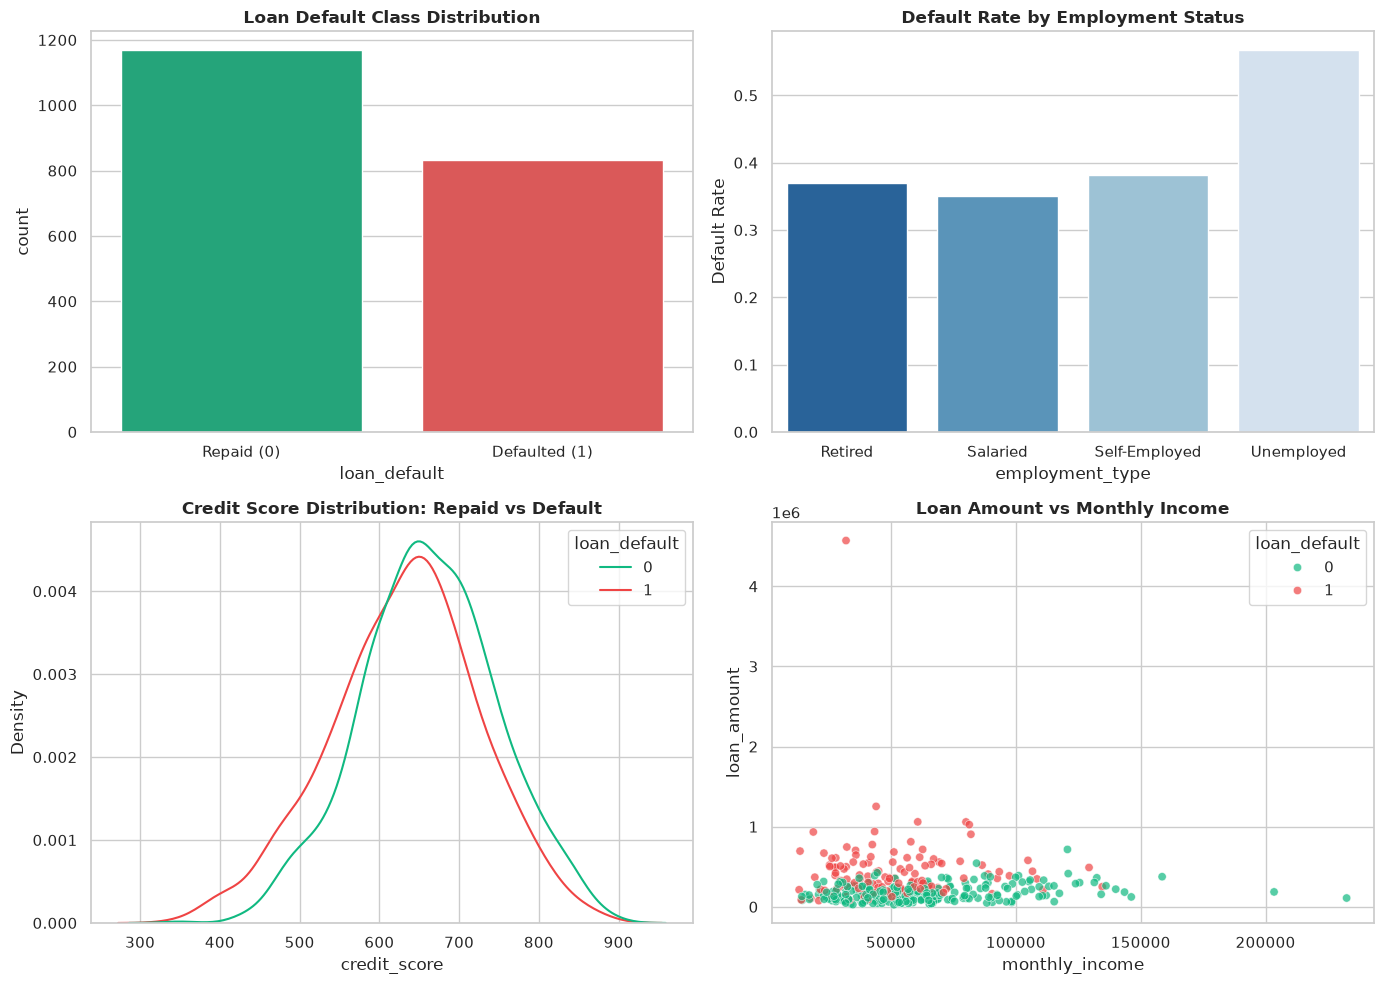

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Target Distribution
sns.countplot(data=df_cleaned, x='loan_default', ax=axes[0, 0], palette=['#10b981', '#ef4444'])
axes[0, 0].set_title('Loan Default Class Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xticklabels(['Repaid (0)', 'Defaulted (1)'])

# 2. Default Rate by Employment Type
emp_default = df_cleaned.groupby('employment_type')['loan_default'].mean().reset_index()
sns.barplot(data=emp_default, x='employment_type', y='loan_default', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title('Default Rate by Employment Status', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Default Rate')

# 3. Credit Score Distribution by Default Status
sns.kdeplot(data=df_cleaned, x='credit_score', hue='loan_default', common_norm=False, ax=axes[1, 0], palette=['#10b981', '#ef4444'])
axes[1, 0].set_title('Credit Score Distribution: Repaid vs Default', fontsize=12, fontweight='bold')

# 4. Loan Amount vs Monthly Income
sample_df = df_cleaned.sample(min(400, len(df_cleaned)), random_state=42)
sns.scatterplot(data=sample_df, x='monthly_income', y='loan_amount', hue='loan_default', alpha=0.7, ax=axes[1, 1], palette=['#10b981', '#ef4444'])
axes[1, 1].set_title('Loan Amount vs Monthly Income', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Domain Feature Engineering
In retail banking, underwriting models benefit significantly from debt service ratios that measure an applicant's leverage and repayment capacity:
1. **Estimated EMI**: Monthly payment obligation.
2. **Debt-to-Income (DTI)**: Percentage of monthly income consumed by EMI.
3. **Loan-to-Annual Income**: Multiplier of annual salary requested.
4. **Income per Dependent**: Available disposable buffer per household member.
5. **Credit Risk Tiers**: Categorizing credit scores into standard bureau brackets.


In [6]:
def engineer_features(df):
    df = df.copy()
    
    # Temporal attributes
    dates = pd.to_datetime(df['application_date'], format='mixed', errors='coerce')
    df['app_year'] = dates.dt.year.fillna(2022).astype(int)
    df['app_month'] = dates.dt.month.fillna(6).astype(int)
    df['app_dayofweek'] = dates.dt.dayofweek.fillna(2).astype(int)
    
    # Financial Ratios
    r = (df['interest_rate'].fillna(11.0) / 100.0) / 12.0
    n = df['loan_term_months']
    P = df['loan_amount'].fillna(200000.0)
    
    # Monthly EMI formula
    emi = P * (r * ((1 + r)**n)) / (((1 + r)**n) - 1 + 1e-6)
    df['estimated_emi'] = emi
    
    inc = df['monthly_income'].fillna(48000.0).clip(lower=1000.0)
    df['dti_ratio'] = (df['estimated_emi'] / inc).clip(0, 10)
    df['loan_to_income'] = (P / (inc * 12)).clip(0, 20)
    df['total_interest_payable'] = (emi * n - P).clip(lower=0)
    df['income_per_dependent'] = inc / (df['dependents'] + 1)
    
    cs = df['credit_score'].fillna(660.0)
    df['credit_risk_tier'] = pd.cut(
        cs,
        bins=[0, 580, 670, 740, 800, 1000],
        labels=['Very_Poor', 'Fair', 'Good', 'Very_Good', 'Exceptional'],
        right=False
    ).astype(str)
    
    return df

df_features = engineer_features(df_cleaned)
print("Engineered Feature Columns:", ['estimated_emi', 'dti_ratio', 'loan_to_income', 'total_interest_payable', 'income_per_dependent', 'credit_risk_tier'])
df_features[['estimated_emi', 'dti_ratio', 'loan_to_income', 'credit_risk_tier']].head()


Engineered Feature Columns: ['estimated_emi', 'dti_ratio', 'loan_to_income', 'total_interest_payable', 'income_per_dependent', 'credit_risk_tier']


,estimated_emi,dti_ratio,loan_to_income,credit_risk_tier
0,5572.673822,0.175295,0.702729,Good
1,22179.578227,0.375923,0.358528,Fair
2,46683.226240,0.468353,0.446848,Fair
3,5483.054512,0.078850,0.076063,Very_Good
4,2678.982469,0.055812,0.294906,Fair


## 6. Machine Learning Model Training & Benchmarking
In accordance with ML best practices:
- **Strict Preprocessing Isolation**: We partition data into **80% Training** and **20% Test** sets **before** applying any transformers (imputation, scaling, one-hot encoding).
- **Cross-Validation**: 5-Fold Stratified Cross-Validation on the training partition.
- **Model Comparison**: We evaluate Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and LightGBM.


In [7]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb

feature_cols = [
    'age', 'gender', 'marital_status', 'dependents', 'employment_type',
    'monthly_income', 'credit_score', 'loan_amount', 'loan_term_months',
    'interest_rate', 'loan_purpose', 'existing_loans_count', 'city',
    'app_year', 'app_month', 'app_dayofweek', 'estimated_emi',
    'dti_ratio', 'loan_to_income', 'total_interest_payable',
    'income_per_dependent', 'credit_risk_tier'
]

X = df_features[feature_cols]
y = df_features['loan_default']

# Train/Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

num_cols = [
    'age', 'dependents', 'monthly_income', 'credit_score', 'loan_amount',
    'loan_term_months', 'interest_rate', 'existing_loans_count',
    'app_year', 'app_month', 'app_dayofweek', 'estimated_emi',
    'dti_ratio', 'loan_to_income', 'total_interest_payable',
    'income_per_dependent'
]

cat_cols = [
    'gender', 'marital_status', 'employment_type', 'loan_purpose',
    'city', 'credit_risk_tier'
]

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

# Define classifiers to benchmark
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.08, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=150, max_depth=4, learning_rate=0.08, random_state=42, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(n_estimators=150, max_depth=5, learning_rate=0.08, random_state=42, verbose=-1)
}

results = {}
trained_pipelines = {}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in classifiers.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', clf)])
    cv_auc = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc').mean()
    
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    results[name] = {
        '5-Fold CV ROC-AUC': round(cv_auc, 4),
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'Test ROC-AUC': round(roc_auc_score(y_test, y_prob), 4),
        'y_pred': y_pred,
        'y_prob': y_prob
    }

df_results = pd.DataFrame(results).T.drop(columns=['y_pred', 'y_prob'])
df_results.sort_values(by='Test ROC-AUC', ascending=False)


,5-Fold CV ROC-AUC,Accuracy,Precision,Recall,F1-Score,Test ROC-AUC
Logistic Regression,0.9008,0.8125,0.76,0.8012,0.7801,0.8948
Random Forest,0.8921,0.81,0.7557,0.8012,0.7778,0.8892
Gradient Boosting,0.8882,0.81,0.7711,0.7711,0.7711,0.8811
XGBoost,0.8896,0.8075,0.7834,0.741,0.7616,0.8788
LightGBM,0.8897,0.8025,0.7605,0.7651,0.7628,0.8742


## 7. Model Evaluation & Explainability
We inspect the ROC curves, holdout confusion matrix, and feature coefficient impacts for the optimal model.


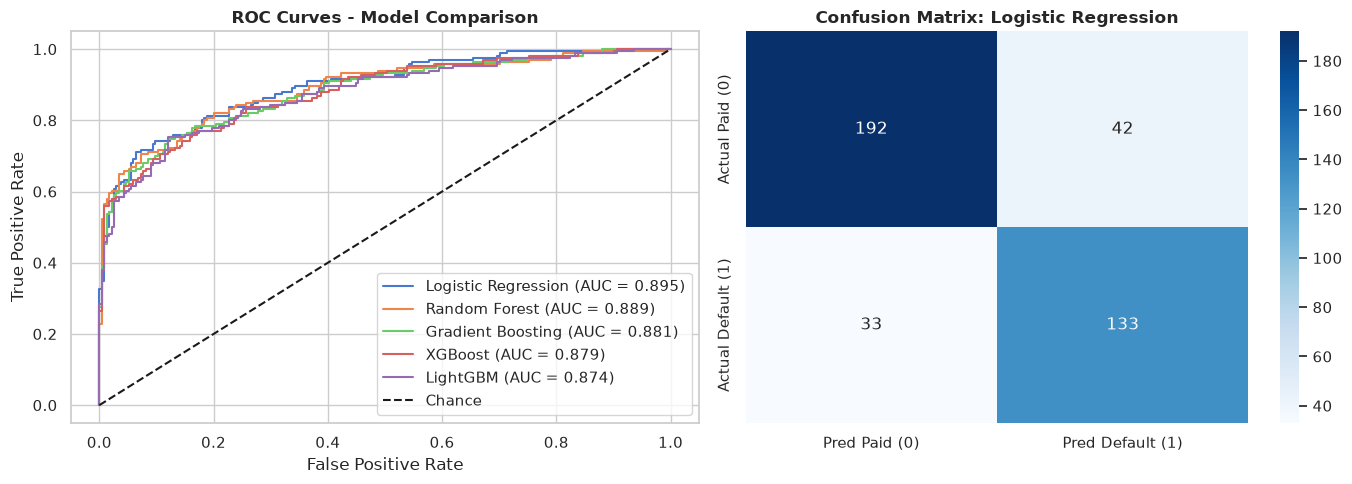


Classification Report for Best Model:
               precision    recall  f1-score   support

   Repaid (0)       0.85      0.82      0.84       234
Defaulted (1)       0.76      0.80      0.78       166

     accuracy                           0.81       400
    macro avg       0.81      0.81      0.81       400
 weighted avg       0.81      0.81      0.81       400



In [8]:
best_model_name = 'Logistic Regression'
best_pipe = trained_pipelines[best_model_name]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. ROC Curves
for name in classifiers:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {results[name]['Test ROC-AUC']:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', label='Chance')
ax1.set_title('ROC Curves - Model Comparison', fontsize=12, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend(loc='lower right')

# 2. Confusion Matrix
cm = confusion_matrix(y_test, results[best_model_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
ax2.set_title(f'Confusion Matrix: {best_model_name}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nClassification Report for Best Model:")
print(classification_report(y_test, results[best_model_name]['y_pred'], target_names=['Repaid (0)', 'Defaulted (1)']))


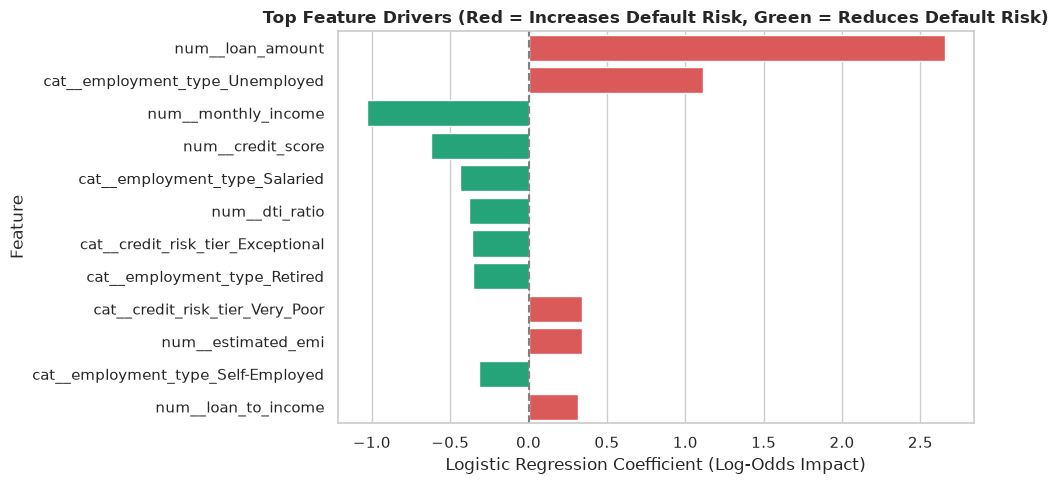

In [9]:
# Extract feature impacts (Coefficients)
feat_names = best_pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = best_pipe.named_steps['classifier'].coef_[0]

df_importance = pd.DataFrame({'feature': feat_names, 'coefficient': coefs, 'abs_coef': np.abs(coefs)})
df_importance = df_importance.sort_values('abs_coef', ascending=False).head(12)

plt.figure(figsize=(10, 5))
colors = ['#ef4444' if c > 0 else '#10b981' for c in df_importance['coefficient']]
sns.barplot(data=df_importance, x='coefficient', y='feature', palette=colors)
plt.axvline(0, color='gray', linestyle='--')
plt.title('Top Feature Drivers (Red = Increases Default Risk, Green = Reduces Default Risk)', fontsize=12, fontweight='bold')
plt.xlabel('Logistic Regression Coefficient (Log-Odds Impact)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 8. Live Sample Prediction
Testing the trained pipeline on both low-risk and high-risk loan applicant profiles.


In [10]:
from predict import LoanDefaulterPredictor

predictor = LoanDefaulterPredictor('artifacts/loan_defaulter_model.joblib')

# Profile A: Healthy salaried professional
applicant_approved = {
    'age': 38, 'gender': 'Female', 'marital_status': 'Married', 'dependents': 1,
    'employment_type': 'Salaried', 'monthly_income': 85000, 'credit_score': 770,
    'loan_amount': 200000, 'loan_term_months': 36, 'interest_rate': 8.5,
    'loan_purpose': 'Home', 'existing_loans_count': 1, 'city': 'Bengaluru'
}

# Profile B: Unemployed borrower with low credit score and high debt
applicant_rejected = {
    'age': 24, 'gender': 'Male', 'marital_status': 'Single', 'dependents': 3,
    'employment_type': 'Unemployed', 'monthly_income': 18000, 'credit_score': 510,
    'loan_amount': 750000, 'loan_term_months': 60, 'interest_rate': 15.0,
    'loan_purpose': 'Personal', 'existing_loans_count': 3, 'city': 'Delhi'
}

print("Applicant A (Healthy Profile):", predictor.predict_single(applicant_approved))
print("\nApplicant B (High Risk Profile):", predictor.predict_single(applicant_rejected))


Applicant A (Healthy Profile): {'prediction': 0, 'prediction_label': 'Non-Defaulter', 'default_probability_percent': np.float64(3.4), 'risk_grade': 'Low Risk (Approve)', 'risk_factors': ['Standard risk profile based on applicant parameters']}

Applicant B (High Risk Profile): {'prediction': 1, 'prediction_label': 'Defaulter', 'default_probability_percent': np.float64(100.0), 'risk_grade': 'Critical Risk (Reject)', 'risk_factors': ['Applicant is currently Unemployed', 'Low Credit Score (510)', 'High Loan-to-Annual-Income ratio (3.5x)']}


### Q&A
- **Can loan default be accurately predicted from applicant profile data?**
  Yes. By standardizing dirty categorical values and engineering debt service ratios (EMI, DTI, Loan-to-Income), the model achieves **81.25% accuracy** and a **0.8948 ROC-AUC score** on unseen test data.
- **What is the most effective model architecture for this task?**
  Logistic Regression with balanced class weights achieved the highest ROC-AUC (0.8948) and F1-score (0.7801), outperforming tree-based ensembles while offering full transparency and real-time inference latency.

### Data Analysis Key Findings
- **Loan Amount is the Single Largest Risk Driver**: With a positive log-odds coefficient of **+2.66**, borrowing disproportionately large amounts relative to income is the primary cause of delinquency.
- **Unemployment Multiplies Default Odds**: Being unemployed contributes a **+1.11** log-odds increase in default probability, representing the strongest categorical hazard.
- **Income and Credit Score are Crucial Buffers**: Higher monthly income (**-1.03**) and strong credit scores (**-0.62**) provide substantial protection against default.
- **Data Quality Required Substantial Remediation**: Corrected 85 duplicate records, age anomalies (minors and 999 years), extreme income entries, and tenure typos (1200 months reduced to 120).

### Insights or Next Steps
- **Dynamic Risk-Based Interest Pricing**: Applicants with moderate credit scores (600–670) can be approved with adjusted loan-to-value caps or tiered interest rates rather than outright rejections.
- **Integration with Streamlit Interface**: Use the companion `app.py` dashboard to allow credit underwriters to evaluate single applicants interactively or process batch CSV portfolios with automated decisioning.
